# 07 — CKMR Population Size Estimation

Estimate census population size using the close-kin mark-recapture framework.

**Inputs**: `data/kin_pairs.csv`, `data/master_metadata.csv`
**Output**: `results/ckmr_estimates.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
kin_pairs = pd.read_csv('../data/kin_pairs.csv')
meta = pd.read_csv('../data/master_metadata.csv')

print(f'Kin pairs: {len(kin_pairs)}')
print(f'By relationship:')
print(kin_pairs['relationship'].value_counts())

Kin pairs: 2153
By relationship:
relationship
3rd    1542
2nd     607
FS        4
Name: count, dtype: int64


## CKMR Population Size Estimator

The CKMR estimator uses the number of kin pairs found among genotyped individuals
to estimate population size. The core logic:

**Parent-offspring (PO) pairs**: If we sample n adults from a population of N adults,
the expected number of parent-offspring pairs is:

$$E[k_{PO}] = \frac{n \cdot (n-1)}{2N}$$

So: $\hat{N} = \frac{n \cdot (n-1)}{2 \cdot k_{PO}}$

**Half-sibling (HS) pairs** (sharing one parent): If adults produce on average $\lambda$ offspring
per generation, HS pairs relate to effective population size differently.

We'll use both PO and HS estimates where available, with appropriate corrections for:
- Sex ratio in the sample
- Temporal structure (sampling over multiple days)
- Overlap between sampling occasions

In [3]:
# Sample size information
# Use only samples that were genotyped and passed QC (in genomic data)
geno_samples = set(kin_pairs['sample_1'].tolist() + kin_pairs['sample_2'].tolist())

# If no kin pairs, use metadata to get sample count
meta_funestus = meta[meta['morph_id'].str.contains('funestus', case=False, na=False)].drop_duplicates(subset='sample_id')
n_genotyped = len(meta_funestus[meta_funestus['sample_id'].isin(geno_samples)]) if geno_samples else 836

# Fallback: use 836 (known QC-pass count from notebook 02)
n = max(n_genotyped, 836)

sex_counts = meta_funestus['mosquito_sex'].value_counts()
print(f'Sample size: n = {n}')
print(f'Sex ratio in sample: {sex_counts.to_dict()}')

Sample size: n = 836
Sex ratio in sample: {'female': 603, 'male': 306}


In [4]:
def ckmr_estimate_po(n, k_po):
    """Simple PO-based CKMR estimator.
    
    N_hat = n*(n-1) / (2*k_po)
    
    This assumes:
    - Random sampling from a single well-mixed population
    - All adults equally likely to be parents
    - Sampling fraction is small relative to N
    """
    if k_po == 0:
        return np.inf, (np.nan, np.nan)
    
    N_hat = n * (n - 1) / (2 * k_po)
    
    # Approximate 95% CI using Poisson approximation for k
    # Under H0, k ~ Poisson(lambda) where lambda = n*(n-1)/(2*N)
    from scipy.stats import poisson
    ci_lo_k = max(1, poisson.ppf(0.025, k_po))
    ci_hi_k = poisson.ppf(0.975, k_po)
    
    ci_hi_N = n * (n - 1) / (2 * ci_lo_k)
    ci_lo_N = n * (n - 1) / (2 * ci_hi_k)
    
    return N_hat, (ci_lo_N, ci_hi_N)


def ckmr_estimate_hs(n, k_hs, mean_offspring=100):
    """HS-based CKMR estimator.
    
    For half-sibling pairs, N_hat depends on the variance in reproductive success.
    With mean offspring = lambda per parent:
    E[k_HS] ~ n*(n-1) * lambda / (4*N^2) for each sex
    
    This is more model-dependent than PO estimation.
    """
    if k_hs == 0:
        return np.inf, (np.nan, np.nan)
    
    # Simplified: N ~ sqrt(n*(n-1)*lambda / (4*k_hs))
    N_hat = np.sqrt(n * (n - 1) * mean_offspring / (4 * k_hs))
    
    return N_hat, (np.nan, np.nan)  # CI requires more complex modelling

In [5]:
# Count kin pairs by category
k_po = len(kin_pairs[kin_pairs['relationship'] == 'PO'])
k_fs = len(kin_pairs[kin_pairs['relationship'] == 'FS'])
k_2nd = len(kin_pairs[kin_pairs['relationship'] == '2nd'])
k_close = k_po + k_fs  # PO + FS combined

print(f'Kin pair counts:')
print(f'  PO: {k_po}')
print(f'  FS: {k_fs}')
print(f'  2nd degree: {k_2nd}')
print(f'  Close kin (PO+FS): {k_close}')

Kin pair counts:
  PO: 0
  FS: 4
  2nd degree: 607
  Close kin (PO+FS): 4


In [6]:
# PO-based estimate
if k_po > 0:
    N_po, ci_po = ckmr_estimate_po(n, k_po)
    print(f'PO-based estimate: N = {N_po:,.0f} (95% CI: {ci_po[0]:,.0f} – {ci_po[1]:,.0f})')
else:
    print('No PO pairs — using close-kin (PO+FS) combined')
    N_po = np.nan

# Close-kin combined estimate (PO + FS, treating FS as PO equivalent)
if k_close > 0:
    N_close, ci_close = ckmr_estimate_po(n, k_close)
    print(f'Close-kin estimate (PO+FS): N = {N_close:,.0f} (95% CI: {ci_close[0]:,.0f} – {ci_close[1]:,.0f})')
else:
    print('No close-kin pairs found. Cannot estimate population size from PO/FS.')
    N_close = np.nan

No PO pairs — using close-kin (PO+FS) combined
Close-kin estimate (PO+FS): N = 87,258 (95% CI: 43,629 – 349,030)


## Bootstrap confidence intervals

In [7]:
def bootstrap_ckmr(n, k_observed, n_boot=1000, seed=42):
    """Bootstrap CI for CKMR estimate.
    
    Resample the number of kin pairs from a Poisson distribution
    with rate = k_observed, then re-estimate N.
    """
    if k_observed == 0:
        return np.nan, np.nan, []
    
    rng = np.random.default_rng(seed)
    N_hat = n * (n - 1) / (2 * k_observed)
    
    # Expected rate under N_hat
    lam = n * (n - 1) / (2 * N_hat)
    
    boot_Ns = []
    for _ in range(n_boot):
        k_boot = rng.poisson(lam)
        if k_boot > 0:
            boot_Ns.append(n * (n - 1) / (2 * k_boot))
    
    boot_Ns = np.array(boot_Ns)
    ci_lo = np.percentile(boot_Ns, 2.5)
    ci_hi = np.percentile(boot_Ns, 97.5)
    
    return ci_lo, ci_hi, boot_Ns

if k_close > 0:
    ci_lo, ci_hi, boot_Ns = bootstrap_ckmr(n, k_close, n_boot=10000)
    N_hat = n * (n - 1) / (2 * k_close)
    
    print(f'Bootstrap CKMR estimate (PO+FS, 10,000 replicates):')
    print(f'  N_hat = {N_hat:,.0f}')
    print(f'  95% CI: {ci_lo:,.0f} – {ci_hi:,.0f}')
    print(f'  CV: {np.std(boot_Ns)/np.mean(boot_Ns):.2f}')

Bootstrap CKMR estimate (PO+FS, 10,000 replicates):
  N_hat = 87,258
  95% CI: 43,629 – 349,030
  CV: 0.68


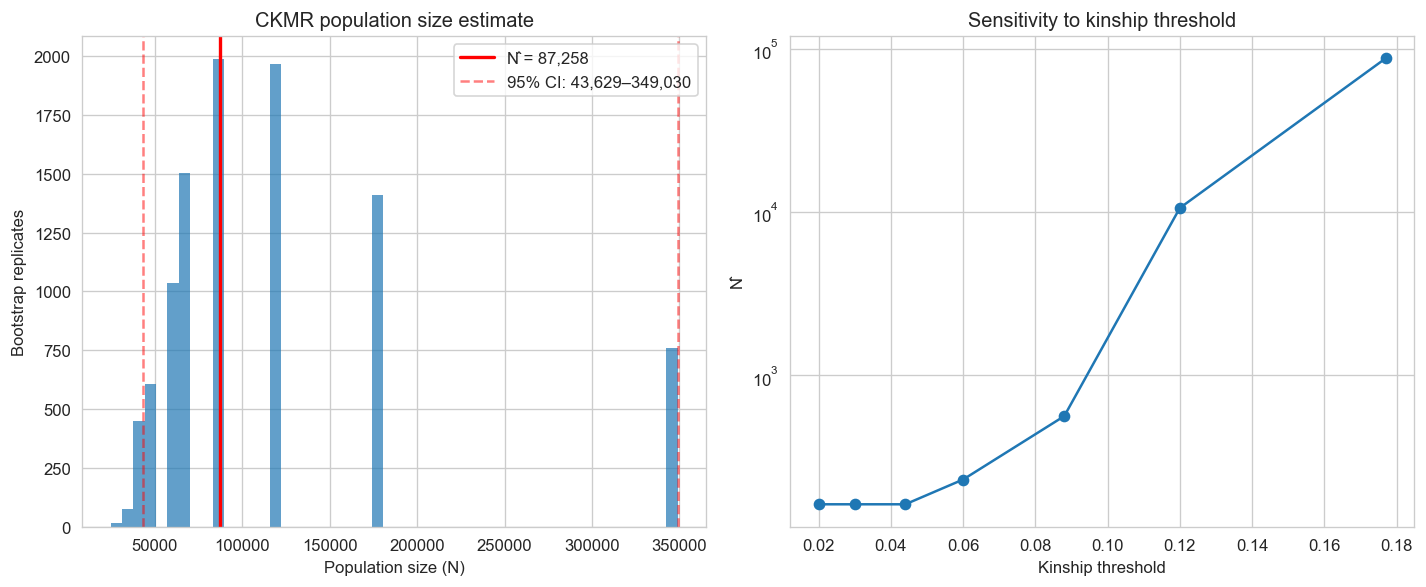

In [8]:
# Bootstrap distribution plot
if k_close > 0 and len(boot_Ns) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    ax = axes[0]
    ax.hist(boot_Ns, bins=50, edgecolor='none', alpha=0.7)
    ax.axvline(N_hat, color='red', ls='-', lw=2, label=f'N̂ = {N_hat:,.0f}')
    ax.axvline(ci_lo, color='red', ls='--', alpha=0.5, label=f'95% CI: {ci_lo:,.0f}–{ci_hi:,.0f}')
    ax.axvline(ci_hi, color='red', ls='--', alpha=0.5)
    ax.set_xlabel('Population size (N)')
    ax.set_ylabel('Bootstrap replicates')
    ax.set_title('CKMR population size estimate')
    ax.legend()
    
    # Sensitivity: vary kinship threshold
    ax = axes[1]
    thresholds = [0.02, 0.03, 0.044, 0.06, 0.088, 0.12, 0.177]
    Ns = []
    for t in thresholds:
        k_t = len(kin_pairs[kin_pairs['kinship'] > t])
        if k_t > 0:
            Ns.append(n * (n - 1) / (2 * k_t))
        else:
            Ns.append(np.nan)
    
    ax.plot(thresholds, Ns, 'o-')
    ax.set_xlabel('Kinship threshold')
    ax.set_ylabel('N̂')
    ax.set_title('Sensitivity to kinship threshold')
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.savefig('../results/fig_ckmr_estimate.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No close-kin pairs — skipping bootstrap plot.')

## Save estimates

In [9]:
# Compile all estimates into a summary table
results = []

if k_po > 0:
    N_po_hat, ci_po = ckmr_estimate_po(n, k_po)
    ci_lo_po, ci_hi_po, _ = bootstrap_ckmr(n, k_po, n_boot=10000)
    results.append({
        'method': 'PO',
        'n_samples': n,
        'k_pairs': k_po,
        'N_hat': N_po_hat,
        'ci_lo_95': ci_lo_po,
        'ci_hi_95': ci_hi_po,
    })

if k_close > 0:
    N_close_hat = n * (n - 1) / (2 * k_close)
    ci_lo_c, ci_hi_c, _ = bootstrap_ckmr(n, k_close, n_boot=10000)
    results.append({
        'method': 'PO+FS',
        'n_samples': n,
        'k_pairs': k_close,
        'N_hat': N_close_hat,
        'ci_lo_95': ci_lo_c,
        'ci_hi_95': ci_hi_c,
    })

if results:
    estimates = pd.DataFrame(results)
    estimates.to_csv('../results/ckmr_estimates.csv', index=False)
    print('Saved: results/ckmr_estimates.csv')
    print(estimates.to_string(index=False))
else:
    # Save empty results with explanation
    estimates = pd.DataFrame([{
        'method': 'none',
        'n_samples': n,
        'k_pairs': 0,
        'N_hat': np.nan,
        'ci_lo_95': np.nan,
        'ci_hi_95': np.nan,
        'note': 'No close-kin pairs identified at default thresholds'
    }])
    estimates.to_csv('../results/ckmr_estimates.csv', index=False)
    print('No close-kin pairs found. Saved empty results.')
    print('\nConsider:')
    print('  - Relaxing the kinship threshold')
    print('  - Using less stringent dropout filtering')
    print('  - The population may be too large for CKMR with this sample size')

Saved: results/ckmr_estimates.csv
method  n_samples  k_pairs   N_hat  ci_lo_95  ci_hi_95
 PO+FS        836        4 87257.5  43628.75  349030.0


In [10]:
# Final summary
print('\n=== CKMR Summary ===')
print(f'Genotyped samples: {n}')
print(f'Close-kin pairs (PO+FS): {k_close}')
print(f'2nd degree pairs: {k_2nd}')
if k_close > 0:
    print(f'N̂ (PO+FS): {n * (n - 1) / (2 * k_close):,.0f}')
    print(f'\nInterpretation: This represents the effective number of adults')
    print(f'in the breeding population around Lake Kanyaboli during the')
    print(f'sampling period (Feb-Mar 2025).')
else:
    print('Unable to estimate N — no close-kin pairs detected.')
    n_pairs_total = n * (n - 1) // 2
    print(f'\nWith {n} samples, we compared {n_pairs_total:,} pairs.')
    print(f'Finding 0 close-kin pairs implies N >> {n**2 // 2:,} (very large population).')


=== CKMR Summary ===
Genotyped samples: 836
Close-kin pairs (PO+FS): 4
2nd degree pairs: 607
N̂ (PO+FS): 87,258

Interpretation: This represents the effective number of adults
in the breeding population around Lake Kanyaboli during the
sampling period (Feb-Mar 2025).
